<a href="https://colab.research.google.com/github/Aaaaddddyyyyyyyy/Machine-Learning-repo/blob/main/Gradient_boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)
X=np.random.rand(100,1)-0.5
y=3*X[:,0]**2 + 0.05*np.random.randn(100)

In [4]:
df=pd.DataFrame()


In [6]:
df['X']=X.reshape(100)
df['y']=y
df

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


Text(0.5, 1.0, ' X vs y')

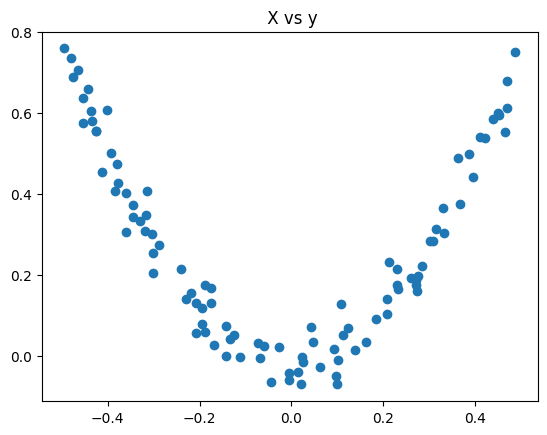

In [7]:
plt.scatter(df['X'],df['y'])
plt.title(' X vs y')

In [10]:
# applying gradient boosting
# step 1= making the small models
df['pred1']=df['y'].mean()          # as 1st model is mean ofd outpout column
df.head()

,X,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458


In [12]:
# step 2= finding the residual of 1st model
df['res1']=df['y']-df['pred1']
df.head()

,X,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528


In [13]:
from sklearn.tree import DecisionTreeRegressor

In [14]:
tree1=DecisionTreeRegressor(max_leaf_nodes=8)

In [15]:
tree1.fit(df['X'].values.reshape(100,1),df['res1'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

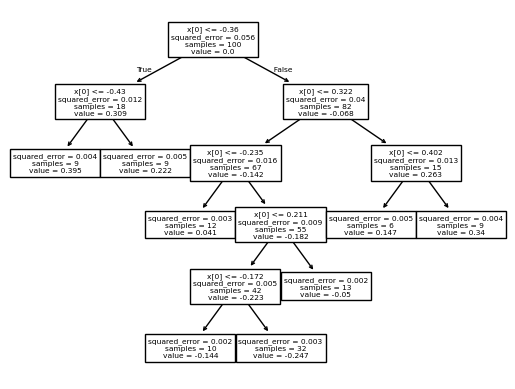

In [16]:
from sklearn.tree import plot_tree
plot_tree(tree1)
plt.show()

In [17]:
# genetrating X test
X_test=np.linspace(-0.5,0.5,500)


In [18]:
y_pred=0.26+ tree1.predict(X_test.reshape(500,1))

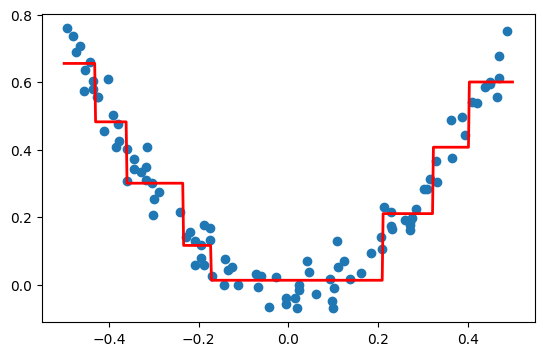

In [19]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test,y_pred,linewidth=2,color='red')
plt.scatter(df['X'],df['y'])

In [20]:
df['pred2']= 0.264+ tree1.predict(df['X'].values.reshape(100,1))

In [21]:
df


,X,y,pred1,res1,pred2
0,-0.125460,0.051573,0.265458,-0.213885,0.016861
1,0.450714,0.594480,0.265458,0.329021,0.604426
2,0.231994,0.166052,0.265458,-0.099407,0.214326
3,0.098658,-0.070178,0.265458,-0.335636,0.016861
4,-0.343981,0.343986,0.265458,0.078528,0.304506
...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.016861
96,0.022733,-0.002305,0.265458,-0.267763,0.016861
97,-0.072459,0.032809,0.265458,-0.232650,0.016861
98,-0.474581,0.689516,0.265458,0.424057,0.659454


In [22]:
df['res2']=df['y']-df['pred2']
df.head()

,X,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.016861,0.034712
1,0.450714,0.594480,0.265458,0.329021,0.604426,-0.009946
2,0.231994,0.166052,0.265458,-0.099407,0.214326,-0.048274
3,0.098658,-0.070178,0.265458,-0.335636,0.016861,-0.087039
4,-0.343981,0.343986,0.265458,0.078528,0.304506,0.039480


In [24]:
tree2=DecisionTreeRegressor(max_leaf_nodes=8)

In [25]:
tree2.fit(df['X'].values.reshape(100,1),df['res2'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

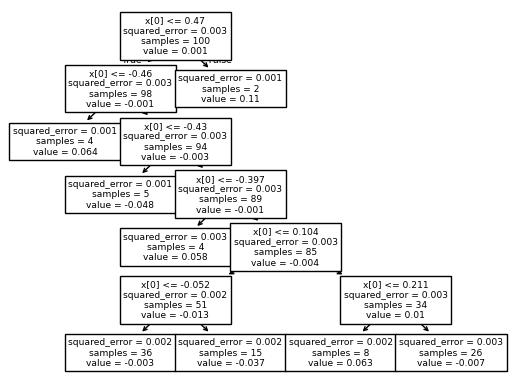

In [26]:
from sklearn.tree import plot_tree
plot_tree(tree2)
plt.show()

In [27]:
X_test=np.linspace(-0.5,0,500)

In [28]:
y_pred1=0.26+ tree2.predict(X_test.reshape(500,1))

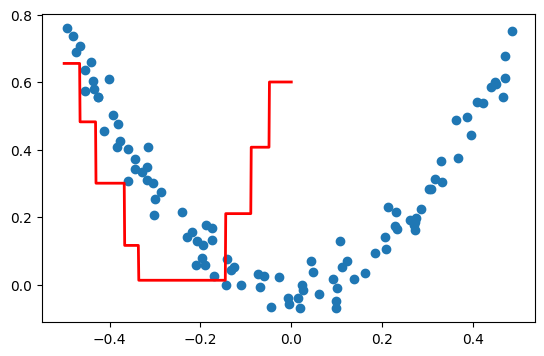

In [34]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test,y_pred,linewidth=2,color='red')
plt.scatter(df['X'],df['y'])